<a href="https://colab.research.google.com/github/AshutoshPant746/PatternRecognition/blob/gh-pages/Pattern_recognition_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Polynomial Degree: 3
Linear Regression -> MSE: 36131.49, R²: 0.7070
Polynomial Regression -> MSE: 1690.71, R²: 0.9863


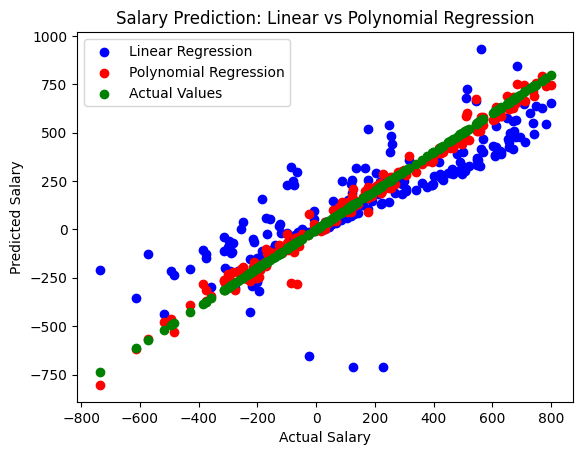

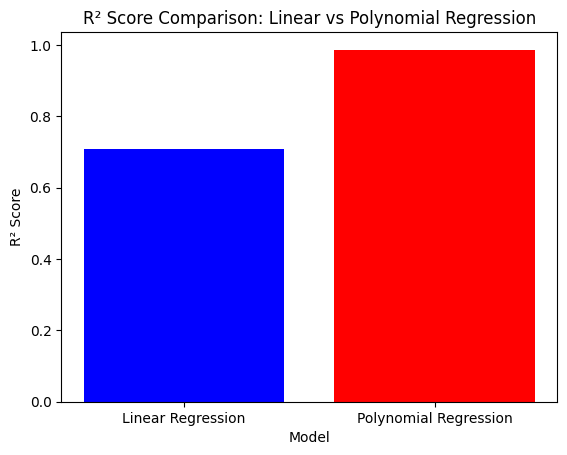

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import operator
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Generate synthetic dataset with 1000 samples
np.random.seed(0)
n_samples = 1000
X = np.random.normal(0, 1, (n_samples, 4))  # 4 independent variables
y = (
    3 * (X[:, 0] ** 2) - 5 * (X[:, 1] ** 2) +
    2 * (X[:, 0] * X[:, 1]) +
    500 * np.sin(X[:, 2]) + 300 * np.cos(X[:, 3]) +
    np.random.normal(0, 10, n_samples)
)

# Convert to DataFrame
data = pd.DataFrame(X, columns=['Experience', 'Age', 'Education Level', 'Job Level'])
data['Salary'] = y

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data[['Experience', 'Age', 'Education Level', 'Job Level']], data['Salary'], test_size=0.2, random_state=42)

# Train linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Apply polynomial regression
degree = 3  # Experiment with different degrees
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate models
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Degree: {degree}")
print(f"Linear Regression -> MSE: {mse_linear:.2f}, R²: {r2_linear:.4f}")
print(f"Polynomial Regression -> MSE: {mse_poly:.2f}, R²: {r2_poly:.4f}")

# Scatter plot
plt.scatter(y_test, y_pred_linear, color='blue', label='Linear Regression')
plt.scatter(y_test, y_pred_poly, color='red', label='Polynomial Regression')
plt.scatter(y_test, y_test, color='green', label='Actual Values')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.legend()
plt.title("Salary Prediction: Linear vs Polynomial Regression")
plt.show()

# Bar plot for R² comparison
models = ['Linear Regression', 'Polynomial Regression']
r2_scores = [r2_linear, r2_poly]

fig, ax = plt.subplots()
ax.bar(models, r2_scores, color=['blue', 'red'])
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison: Linear vs Polynomial Regression')

plt.show()
